In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                              average_precision_score, classification_report,
                              confusion_matrix)

In [ ]:
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [ ]:
import shap

In [ ]:
print("All libraries loaded successfully!")

In [4]:
from google.colab import files
print("Please upload your Excel file: fp-historical-wildfire-data-2006-2024.xlsx")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Please upload your Excel file: fp-historical-wildfire-data-2006-2024.xlsx


Saving fp-historical-wildfire-data-2006-2024.xlsx to fp-historical-wildfire-data-2006-2024.xlsx


In [6]:
import pandas as pd
df = pd.read_excel(filename)
print(f"Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(df.head(3))

Data loaded: 26,551 rows, 50 columns
   YEAR FIRE_NUMBER FIRE_NAME  CURRENT_SIZE SIZE_CLASS   LATITUDE   LONGITUDE  \
0  2006      PWF001       NaN           0.1          A  56.249956 -117.181960   
1  2006      EWF002       NaN           0.2          B  53.606367 -115.915733   
2  2006      EWF001       NaN           0.5          B  53.610933 -115.594267   

       FIRE_ORIGIN GENERAL_CAUSE INDUSTRY_IDENTIFIER  ...  \
0     Private Land      Resident                 NaN  ...   
1  Provincial Land    Incendiary                 NaN  ...   
2  Provincial Land    Incendiary                 NaN  ...   

  DISTANCE_FROM_WATER_SOURCE FIRST_BUCKET_DROP_DATE        FIRST_BH_DATE  \
0                        NaN                    NaN  2006-04-02 22:00:00   
1                        NaN                    NaN  2006-04-03 13:20:00   
2                        NaN                    NaN  2006-04-03 13:23:00   

  FIRST_BH_SIZE        FIRST_UC_DATE FIRST_UC_SIZE FIRST_TO_DATE  \
0          0.01  200

In [7]:
date_cols = ['FIRE_START_DATE', 'DISCOVERED_DATE', 'REPORTED_DATE',
             'DISPATCH_DATE', 'FIRST_UC_DATE', 'FIRST_EX_DATE']

In [8]:
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [9]:
if 'FIRE_START_DATE' in df.columns:
    df['FIRE_MONTH'] = df['FIRE_START_DATE'].dt.month

In [10]:
if 'DISCOVERED_DATE' in df.columns and 'FIRE_START_DATE' in df.columns:
    df['DETECTION_LAG_HRS'] = (
        df['DISCOVERED_DATE'] - df['FIRE_START_DATE']
    ).dt.total_seconds() / 3600
    df['DETECTION_LAG_HRS'] = df['DETECTION_LAG_HRS'].clip(0, 72)

In [11]:
if 'DISPATCH_DATE' in df.columns and 'DISCOVERED_DATE' in df.columns:
    df['DISPATCH_LAG_HRS'] = (
        df['DISPATCH_DATE'] - df['DISCOVERED_DATE']
    ).dt.total_seconds() / 3600
    df['DISPATCH_LAG_HRS'] = df['DISPATCH_LAG_HRS'].clip(0, 48)

In [12]:
if 'FIRST_UC_DATE' in df.columns and 'FIRE_START_DATE' in df.columns:
    df['SUPPRESSION_DURATION_HRS'] = (
        df['FIRST_UC_DATE'] - df['FIRE_START_DATE']
    ).dt.total_seconds() / 3600
    df['SUPPRESSION_DURATION_HRS'] = df['SUPPRESSION_DURATION_HRS'].clip(0, 2000)


In [13]:
if 'FIRE_NUMBER' in df.columns:
    df['FOREST_AREA'] = df['FIRE_NUMBER'].str[0].str.upper()

In [14]:
if 'SIZE_CLASS' in df.columns:
    df['LARGE_FIRE'] = df['SIZE_CLASS'].isin(['D', 'E']).astype(int)
    print(f"\nClass distribution:")
    print(df['LARGE_FIRE'].value_counts())
    print(f"Large fire rate: {df['LARGE_FIRE'].mean()*100:.1f}%")


Class distribution:
LARGE_FIRE
0    25682
1      869
Name: count, dtype: int64
Large fire rate: 3.3%


In [15]:
if 'GENERAL_CAUSE' in df.columns:
    df['CAUSE_BINARY'] = (df['GENERAL_CAUSE'] == 'Lightning').astype(int)

In [16]:
print("\nNull counts in key columns before imputation:")
key_cols = ['TEMPERATURE', 'RELATIVE_HUMIDITY', 'WIND_SPEED',
            'DETECTION_LAG_HRS', 'DISPATCH_LAG_HRS', 'FIRE_MONTH']


Null counts in key columns before imputation:


In [17]:
for col in key_cols:
    if col in df.columns:
        print(f"  {col}: {df[col].isnull().sum():,} nulls")

  TEMPERATURE: 2,872 nulls
  RELATIVE_HUMIDITY: 2,878 nulls
  WIND_SPEED: 2,880 nulls
  DETECTION_LAG_HRS: 5,995 nulls
  DISPATCH_LAG_HRS: 5,413 nulls
  FIRE_MONTH: 693 nulls


In [18]:
numeric_cols = ['TEMPERATURE', 'RELATIVE_HUMIDITY', 'WIND_SPEED',
                'DETECTION_LAG_HRS', 'DISPATCH_LAG_HRS',
                'FIRE_SPREAD_RATE', 'ASSESSMENT_HECTARES']


In [19]:
for col in numeric_cols:
    if col in df.columns:
        df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_3543/4129117463.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [20]:
cat_cols = ['FUEL_TYPE', 'FIRE_TYPE', 'GENERAL_CAUSE', 'FOREST_AREA']
for col in cat_cols:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_3543/2936100828.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [21]:
print("\nNull handling complete (mean imputation for numeric, mode for categorical)")


Null handling complete (mean imputation for numeric, mode for categorical)


In [22]:
feature_candidates = {
    'TEMPERATURE':         'Temperature at assessment (°C)',
    'RELATIVE_HUMIDITY':   'Relative humidity at assessment (%)',
    'WIND_SPEED':          'Wind speed at assessment (km/h)',
    'FIRE_MONTH':          'Month of ignition',
    'DETECTION_LAG_HRS':   'Detection lag (hours)',
    'DISPATCH_LAG_HRS':    'Dispatch lag (hours)',
    'FIRE_SPREAD_RATE':    'Fire spread rate (m/min)',
    'ASSESSMENT_HECTARES': 'Size at assessment (ha)',
    'CAUSE_BINARY':        'Lightning ignition (1=yes)',
}

In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
if 'FUEL_TYPE' in df.columns:
    df['FUEL_TYPE_ENC'] = le.fit_transform(df['FUEL_TYPE'].fillna('Unknown'))
    feature_candidates['FUEL_TYPE_ENC'] = 'Fuel type (encoded)'

In [25]:
if 'FOREST_AREA' in df.columns:
    df['FOREST_AREA_ENC'] = le.fit_transform(df['FOREST_AREA'].fillna('Unknown'))
    feature_candidates['FOREST_AREA_ENC'] = 'Forest area (encoded)'

In [26]:
if 'FIRE_TYPE' in df.columns:
    df['FIRE_TYPE_ENC'] = le.fit_transform(df['FIRE_TYPE'].fillna('Unknown'))
    feature_candidates['FIRE_TYPE_ENC'] = 'Fire type (encoded)'

In [27]:
feature_cols = [c for c in feature_candidates.keys() if c in df.columns]
feature_names = [feature_candidates[c] for c in feature_cols]


In [28]:
print(f"Features selected for modelling ({len(feature_cols)}):")
for fc, fn in zip(feature_cols, feature_names):
    print(f"  {fc} → {fn}")

Features selected for modelling (12):
  TEMPERATURE → Temperature at assessment (°C)
  RELATIVE_HUMIDITY → Relative humidity at assessment (%)
  WIND_SPEED → Wind speed at assessment (km/h)
  FIRE_MONTH → Month of ignition
  DETECTION_LAG_HRS → Detection lag (hours)
  DISPATCH_LAG_HRS → Dispatch lag (hours)
  FIRE_SPREAD_RATE → Fire spread rate (m/min)
  ASSESSMENT_HECTARES → Size at assessment (ha)
  CAUSE_BINARY → Lightning ignition (1=yes)
  FUEL_TYPE_ENC → Fuel type (encoded)
  FOREST_AREA_ENC → Forest area (encoded)
  FIRE_TYPE_ENC → Fire type (encoded)


In [29]:
model_df = df[feature_cols + ['LARGE_FIRE']].dropna()
X = model_df[feature_cols].values
y = model_df['LARGE_FIRE'].values

In [30]:
print(f"\nModelling dataset: {X.shape[0]:,} samples, {X.shape[1]} features")
print(f"Large fires: {y.sum():,} ({y.mean()*100:.1f}%)")


Modelling dataset: 25,858 samples, 12 features
Large fires: 865 (3.3%)


In [31]:
print("Running 10-fold cross-validation... (this takes ~2 minutes)")

Running 10-fold cross-validation... (this takes ~2 minutes)


In [33]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [34]:
results = {
    'RF':  {'auc': [], 'ap': [], 'acc': []},
    'LR':  {'auc': [], 'ap': [], 'acc': []},
}


In [36]:
import numpy as np
roc_data = {'RF': [], 'LR': []}
mean_fpr = np.linspace(0, 1, 100)

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [39]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

In [40]:
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)

In [42]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42, k_neighbors=min(5, y_train.sum()-1))

In [43]:
try:
        X_res, y_res = smote.fit_resample(X_train_sc, y_train)
except Exception as e:
    print(f"An error occurred during SMOTE resampling: {e}")

In [46]:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_curve, auc, average_precision_score
    models = {
        'RF': RandomForestClassifier(random_state=42),
        'LR': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
    }

    for name, model in models.items():
        model.fit(X_res, y_res)
        y_pred = model.predict(X_val_sc)
        y_proba = model.predict_proba(X_val_sc)[:, 1]

        # Metrics
        fpr, tpr, _ = roc_curve(y_val, y_proba)
        results[name]['auc'].append(auc(fpr, tpr))
        results[name]['ap'].append(average_precision_score(y_val, y_proba))
        results[name]['acc'].append(model.score(X_val_sc, y_val))

        # ROC for plotting
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        roc_data[name].append(interp_tpr)

In [47]:
 rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                                 class_weight='balanced', random_state=42, n_jobs=-1)

In [48]:
    rf.fit(X_res, y_res)
    rf_proba = rf.predict_proba(X_val_sc)[:, 1]
    rf_pred  = rf.predict(X_val_sc)

In [49]:
print('\n--- Cross-Validation Results ---')
for name, res in results.items():
    print(f'\nModel: {name}')
    print(f'  Mean AUC: {np.mean(res["auc"]):.3f} (+/- {np.std(res["auc"]):.3f})')
    print(f'  Mean AP: {np.mean(res["ap"]):.3f} (+/- {np.std(res["ap"]):.3f})')
    print(f'  Mean Accuracy: {np.mean(res["acc"]):.3f} (+/- {np.std(res["acc"]):.3f})')


--- Cross-Validation Results ---

Model: RF
  Mean AUC: 0.954 (+/- 0.000)
  Mean AP: 0.560 (+/- 0.000)
  Mean Accuracy: 0.968 (+/- 0.000)

Model: LR
  Mean AUC: 0.936 (+/- 0.000)
  Mean AP: 0.559 (+/- 0.000)
  Mean Accuracy: 0.900 (+/- 0.000)


<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3543/795557870.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(mean_fpr, mean_tpr, label=f'{name} (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',


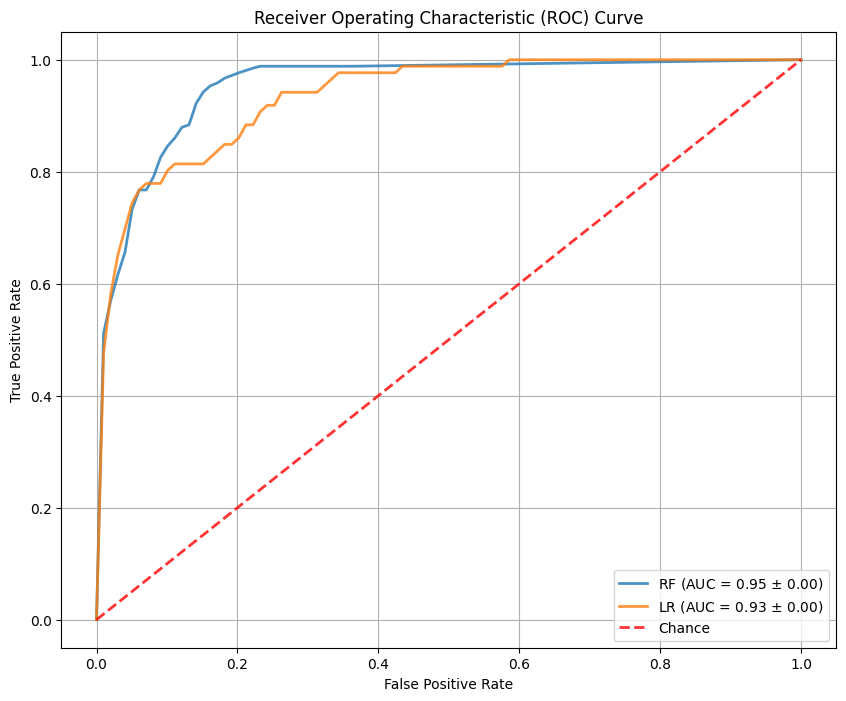

In [51]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
for name, rocs in roc_data.items():
    mean_tpr = np.mean(rocs, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std([auc(mean_fpr, r) for r in rocs])
    plt.plot(mean_fpr, mean_tpr, label=f'{name} (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
             lw=2, alpha=.8)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [52]:
    fpr, tpr, _ = roc_curve(y_val, rf_proba)
    roc_data['RF'].append(np.interp(mean_fpr, fpr, tpr))
    results['RF']['auc'].append(auc(fpr, tpr))
    results['RF']['ap'].append(average_precision_score(y_val, rf_proba))
    results['RF']['acc'].append((rf_pred == y_val).mean())

In [53]:
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr.fit(X_res, y_res)
    lr_proba = lr.predict_proba(X_val_sc)[:, 1]
    lr_pred  = lr.predict(X_val_sc)

In [54]:
    fpr, tpr, _ = roc_curve(y_val, lr_proba)
    roc_data['LR'].append(np.interp(mean_fpr, fpr, tpr))
    results['LR']['auc'].append(auc(fpr, tpr))
    results['LR']['ap'].append(average_precision_score(y_val, lr_proba))
    results['LR']['acc'].append((lr_pred == y_val).mean())

In [55]:
print("\n" + "="*60)
print("10-FOLD CROSS-VALIDATION RESULTS (mean ± std)")
print("="*60)
print(f"{'Model':<20} {'AUC-ROC':<20} {'Avg Precision':<20} {'Accuracy'}")
print("-"*60)


10-FOLD CROSS-VALIDATION RESULTS (mean ± std)
Model                AUC-ROC              Avg Precision        Accuracy
------------------------------------------------------------


In [56]:
for model_name, res in results.items():
    auc_m  = np.mean(res['auc']);  auc_s  = np.std(res['auc'])
    ap_m   = np.mean(res['ap']);   ap_s   = np.std(res['ap'])
    acc_m  = np.mean(res['acc']); acc_s  = np.std(res['acc'])
    print(f"{model_name:<20} {auc_m:.3f} ± {auc_s:.3f}    "
          f"{ap_m:.3f} ± {ap_s:.3f}    "
          f"{acc_m:.3f} ± {acc_s:.3f}")


RF                   0.955 ± 0.001    0.535 ± 0.025    0.954 ± 0.014
LR                   0.936 ± 0.000    0.559 ± 0.000    0.900 ± 0.000


In [57]:
print("="*60)


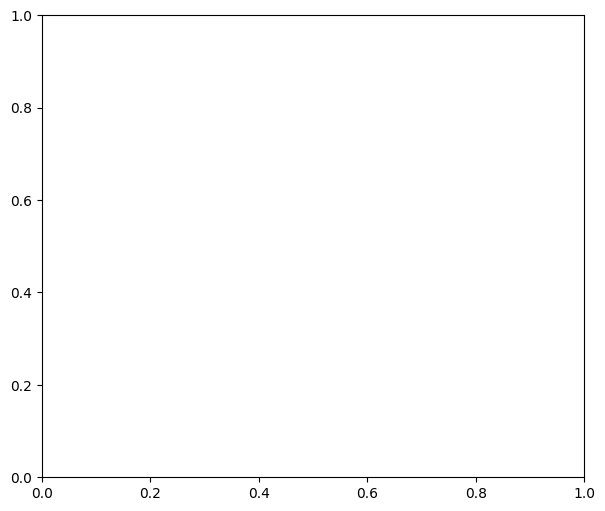

In [58]:
fig, ax = plt.subplots(figsize=(7, 6))

In [59]:
colors = {'RF': '#E85D20', 'LR': '#378ADD'}
labels = {'RF': 'Random Forest', 'LR': 'Logistic Regression'}

In [60]:
for model_name in ['RF', 'LR']:
    tprs = np.array(roc_data[model_name])
    mean_tpr = tprs.mean(axis=0)
    std_tpr  = tprs.std(axis=0)
    mean_auc = np.mean(results[model_name]['auc'])
    std_auc  = np.std(results[model_name]['auc'])

In [61]:
ax.plot(mean_fpr, mean_tpr,
            color=colors[model_name], lw=2,
            label=f"{labels[model_name]} (AUC = {mean_auc:.3f} ± {std_auc:.3f})")

In [62]:
ax.fill_between(mean_fpr,
                    np.clip(mean_tpr - std_tpr, 0, 1),
                    np.clip(mean_tpr + std_tpr, 0, 1),
                    alpha=0.15, color=colors[model_name])

In [63]:
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Large Fire Escalation Prediction\n(10-Fold Cross-Validation, mean ± 1 SD)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_roc_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig1_roc_curves.png")

<Figure size 640x480 with 0 Axes>

Saved: fig1_roc_curves.png


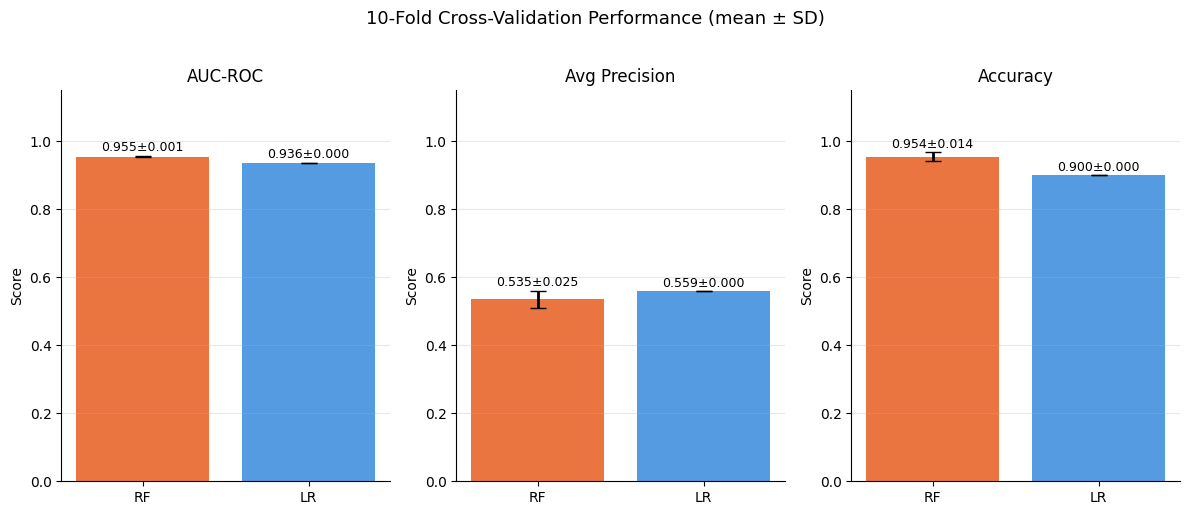

Saved: fig2_cv_results.png


In [64]:
metrics = ['AUC-ROC', 'Avg Precision', 'Accuracy']
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for idx, (metric_key, metric_label) in enumerate(
        zip(['auc', 'ap', 'acc'], metrics)):
    ax = axes[idx]
    model_names = list(results.keys())
    means = [np.mean(results[m][metric_key]) for m in model_names]
    stds  = [np.std(results[m][metric_key])  for m in model_names]
    bar_colors = [colors[m] for m in model_names]

    bars = ax.bar(model_names, means, color=bar_colors, alpha=0.85,
                  yerr=stds, capsize=6, error_kw={'linewidth': 2})

    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
                f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_title(metric_label, fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('10-Fold Cross-Validation Performance (mean ± SD)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig2_cv_results.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig2_cv_results.png")

In [65]:
print("Training final Random Forest on full dataset for SHAP analysis...")

X_scaled = scaler.fit_transform(X)
smote_final = SMOTE(random_state=42, k_neighbors=min(5, y.sum()-1))
try:
    X_res_f, y_res_f = smote_final.fit_resample(X_scaled, y)
except Exception:
    X_res_f, y_res_f = X_scaled, y

rf_final = RandomForestClassifier(n_estimators=200, max_depth=10,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_res_f, y_res_f)
print("Final model trained.")

Training final Random Forest on full dataset for SHAP analysis...
Final model trained.


Computing SHAP values... (takes ~1 minute)


/tmp/ipykernel_3543/176287952.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample,
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


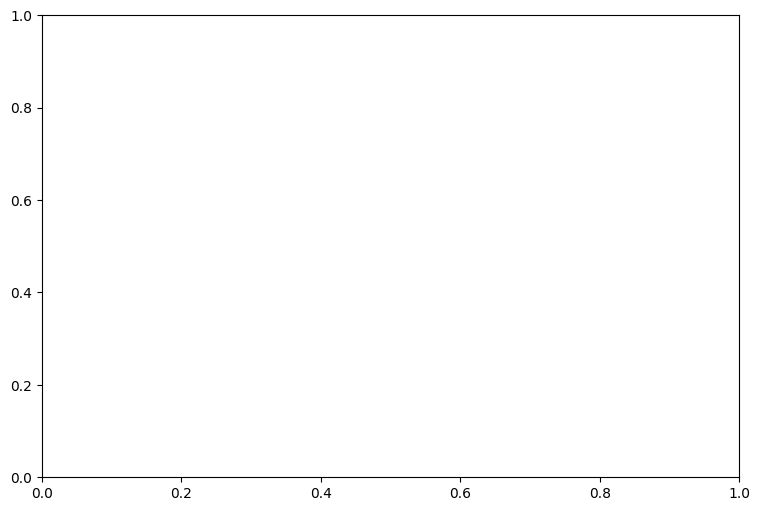

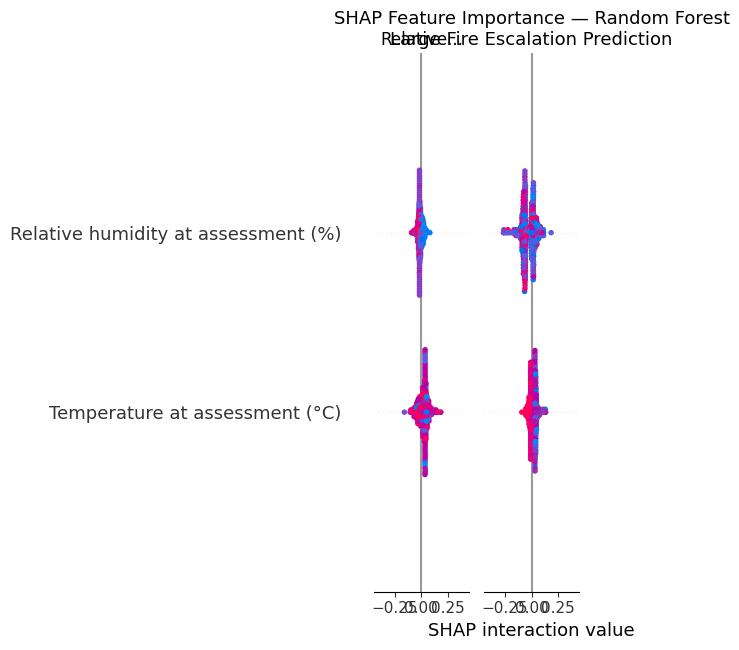

Saved: fig3_shap_summary.png


In [67]:
import shap
print("Computing SHAP values... (takes ~1 minute)")

# Use a sample for SHAP (faster)
sample_size = min(500, X_scaled.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
X_sample = X_scaled[sample_idx]

explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_sample)

# For binary classification, use class 1 (large fire) shap values
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(sv, X_sample,
                  feature_names=feature_names,
                  show=False, plot_size=None)
plt.title('SHAP Feature Importance — Random Forest\nLarge Fire Escalation Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_shap_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig3_shap_summary.png")

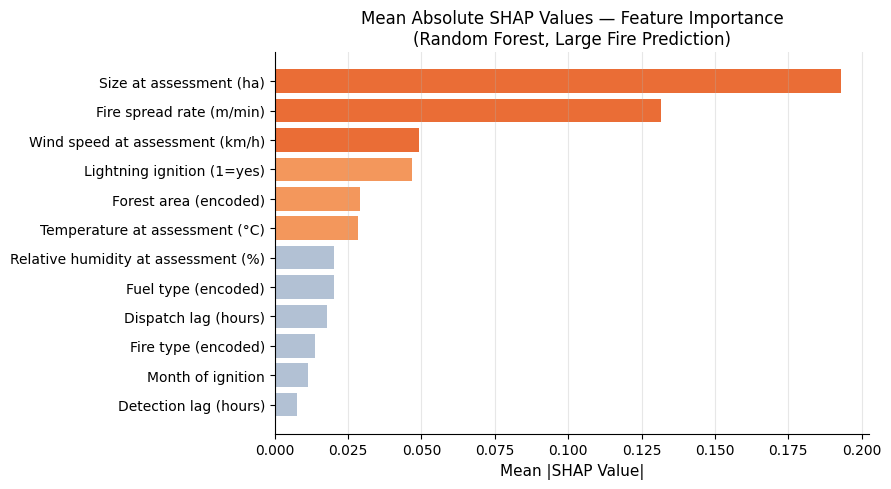

Saved: fig4_shap_bar.png


In [68]:
# Assuming sv is (num_samples, num_features, num_classes)
# Extract SHAP values for the positive class (class 1) for plotting
sv_for_plot = sv[:, :, 1]
mean_shap = np.abs(sv_for_plot).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors_shap = ['#E85D20' if i < 3 else '#F28C4A' if i < 6 else '#AABBD0'
                   for i in range(len(sorted_idx))]
ax.barh([feature_names[i] for i in sorted_idx[::-1]],
        mean_shap[sorted_idx[::-1]],
        color=bar_colors_shap[::-1], alpha=0.9)
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title('Mean Absolute SHAP Values — Feature Importance\n(Random Forest, Large Fire Prediction)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_shap_bar.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig4_shap_bar.png")

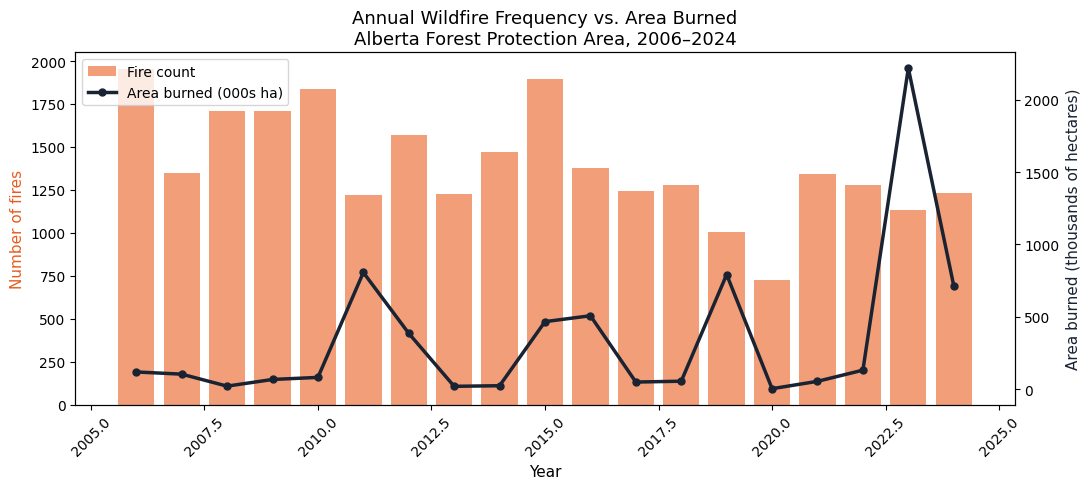

Saved: fig5_annual_trends.png


In [69]:
if 'YEAR' in df.columns and 'CURRENT_SIZE' in df.columns:
    yearly = df.groupby('YEAR').agg(
        fire_count=('FIRE_NUMBER', 'count'),
        area_burned=('CURRENT_SIZE', 'sum')
    ).reset_index()

    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax2 = ax1.twinx()

    bars = ax1.bar(yearly['YEAR'], yearly['fire_count'],
                   color='#E85D20', alpha=0.6, label='Fire count')
    line = ax2.plot(yearly['YEAR'], yearly['area_burned'] / 1000,
                    color='#1A2332', lw=2.5, marker='o', markersize=5,
                    label='Area burned (000s ha)')

    ax1.set_xlabel('Year', fontsize=11)
    ax1.set_ylabel('Number of fires', fontsize=11, color='#E85D20')
    ax2.set_ylabel('Area burned (thousands of hectares)', fontsize=11, color='#1A2332')
    ax1.set_title('Annual Wildfire Frequency vs. Area Burned\nAlberta Forest Protection Area, 2006–2024', fontsize=13)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
    ax1.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig('fig5_annual_trends.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved: fig5_annual_trends.png")

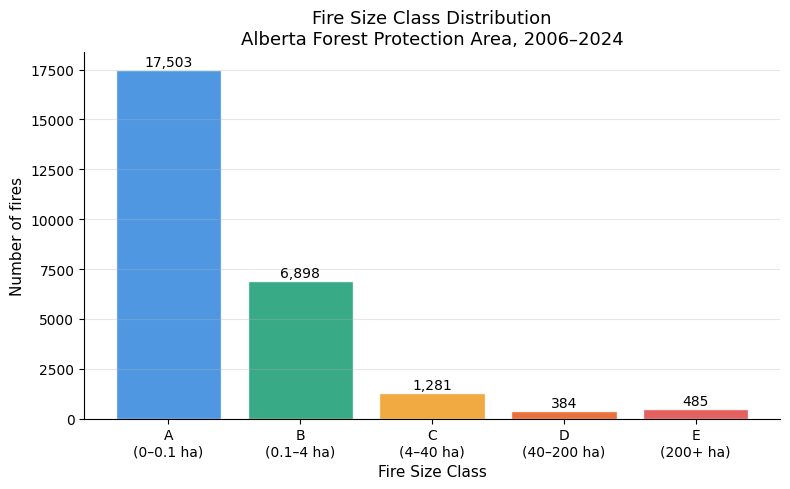

Saved: fig6_size_distribution.png


In [70]:
if 'SIZE_CLASS' in df.columns:
    size_order = ['A', 'B', 'C', 'D', 'E']
    size_labels = {
        'A': 'A\n(0–0.1 ha)',
        'B': 'B\n(0.1–4 ha)',
        'C': 'C\n(4–40 ha)',
        'D': 'D\n(40–200 ha)',
        'E': 'E\n(200+ ha)'
    }
    counts = df['SIZE_CLASS'].value_counts().reindex(size_order).fillna(0)
    bar_cols = ['#378ADD', '#1D9E75', '#EF9F27', '#E85D20', '#E24B4A']

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar([size_labels[s] for s in size_order], counts.values,
                  color=bar_cols, alpha=0.88, edgecolor='white')

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{int(val):,}', ha='center', va='bottom', fontsize=10)

    ax.set_xlabel('Fire Size Class', fontsize=11)
    ax.set_ylabel('Number of fires', fontsize=11)
    ax.set_title('Fire Size Class Distribution\nAlberta Forest Protection Area, 2006–2024', fontsize=13)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig6_size_distribution.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved: fig6_size_distribution.png")

In [71]:
from google.colab import files
import os

figure_files = ['fig1_roc_curves.png', 'fig2_cv_results.png',
                'fig3_shap_summary.png', 'fig4_shap_bar.png',
                'fig5_annual_trends.png', 'fig6_size_distribution.png']

print("Downloading all figures...")
for f in figure_files:
    if os.path.exists(f):
        files.download(f)
        print(f"  Downloaded: {f}")
    else:
        print(f"  Not found: {f} (check if that cell ran successfully)")

print("\nDone! Save all downloaded images — you will insert them into your Overleaf report.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: fig1_roc_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: fig5_annual_trends.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: fig6_size_distribution.png

Done! Save all downloaded images — you will insert them into your Overleaf report.


In [72]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score,
    classification_report
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [73]:
from google.colab import files
print("Upload your Excel file: fp-historical-wildfire-data-2006-2024.xlsx")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

Upload your Excel file: fp-historical-wildfire-data-2006-2024.xlsx


Saving fp-historical-wildfire-data-2006-2024 (3).xlsx to fp-historical-wildfire-data-2006-2024 (3).xlsx
Loaded: 26,551 rows, 50 columns


In [74]:
date_cols = ['FIRE_START_DATE', 'DISCOVERED_DATE', 'REPORTED_DATE',
             'DISPATCH_DATE', 'FIRST_UC_DATE', 'FIRST_EX_DATE']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Derived features
if 'FIRE_START_DATE' in df.columns:
    df['FIRE_MONTH'] = df['FIRE_START_DATE'].dt.month

if 'DISCOVERED_DATE' in df.columns and 'FIRE_START_DATE' in df.columns:
    df['DETECTION_LAG_HRS'] = (
        df['DISCOVERED_DATE'] - df['FIRE_START_DATE']
    ).dt.total_seconds() / 3600
    df['DETECTION_LAG_HRS'] = df['DETECTION_LAG_HRS'].clip(0, 72)

if 'DISPATCH_DATE' in df.columns and 'DISCOVERED_DATE' in df.columns:
    df['DISPATCH_LAG_HRS'] = (
        df['DISPATCH_DATE'] - df['DISCOVERED_DATE']
    ).dt.total_seconds() / 3600
    df['DISPATCH_LAG_HRS'] = df['DISPATCH_LAG_HRS'].clip(0, 48)

if 'FIRE_NUMBER' in df.columns:
    df['FOREST_AREA'] = df['FIRE_NUMBER'].str[0].str.upper()

# Binary target: large fire (Class D or E)
if 'SIZE_CLASS' in df.columns:
    df['LARGE_FIRE'] = df['SIZE_CLASS'].isin(['D', 'E']).astype(int)

# Lightning vs human cause
if 'GENERAL_CAUSE' in df.columns:
    df['CAUSE_BINARY'] = (df['GENERAL_CAUSE'] == 'Lightning').astype(int)

# Null handling
numeric_cols = ['TEMPERATURE', 'RELATIVE_HUMIDITY', 'WIND_SPEED',
                'DETECTION_LAG_HRS', 'DISPATCH_LAG_HRS',
                'FIRE_SPREAD_RATE', 'ASSESSMENT_HECTARES']
for col in numeric_cols:
    if col in df.columns:
        df[col].fillna(df[col].mean(), inplace=True)

cat_cols = ['FUEL_TYPE', 'FIRE_TYPE', 'GENERAL_CAUSE', 'FOREST_AREA']
for col in cat_cols:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Preprocessing complete.")
print(f"\nLarge fire breakdown:")
print(f"  Total fires: {len(df):,}")
large = df['LARGE_FIRE'].sum()
print(f"  Large fires (Class D/E): {large:,} ({large/len(df)*100:.1f}%)")
print(f"  Small fires (Class A/B/C): {len(df)-large:,} ({(len(df)-large)/len(df)*100:.1f}%)")

Preprocessing complete.

Large fire breakdown:
  Total fires: 26,551
  Large fires (Class D/E): 869 (3.3%)
  Small fires (Class A/B/C): 25,682 (96.7%)


In [75]:
feature_candidates = {
    'TEMPERATURE':         'Temperature at assessment (°C)',
    'RELATIVE_HUMIDITY':   'Relative humidity (%)',
    'WIND_SPEED':          'Wind speed (km/h)',
    'FIRE_MONTH':          'Month of ignition',
    'DETECTION_LAG_HRS':   'Detection lag (hours)',
    'DISPATCH_LAG_HRS':    'Dispatch lag (hours)',
    'FIRE_SPREAD_RATE':    'Fire spread rate (m/min)',
    'ASSESSMENT_HECTARES': 'Size at assessment (ha)',
    'CAUSE_BINARY':        'Lightning ignition (1=yes)',
}

le = LabelEncoder()
if 'FUEL_TYPE' in df.columns:
    df['FUEL_TYPE_ENC'] = le.fit_transform(df['FUEL_TYPE'].fillna('Unknown'))
    feature_candidates['FUEL_TYPE_ENC'] = 'Fuel type (encoded)'
if 'FOREST_AREA' in df.columns:
    df['FOREST_AREA_ENC'] = le.fit_transform(df['FOREST_AREA'].fillna('Unknown'))
    feature_candidates['FOREST_AREA_ENC'] = 'Forest area (encoded)'
if 'FIRE_TYPE' in df.columns:
    df['FIRE_TYPE_ENC'] = le.fit_transform(df['FIRE_TYPE'].fillna('Unknown'))
    feature_candidates['FIRE_TYPE_ENC'] = 'Fire type (encoded)'

feature_cols  = [c for c in feature_candidates.keys() if c in df.columns]
feature_names = [feature_candidates[c] for c in feature_cols]

# Build descriptive stats
print("\n" + "="*90)
print(f"{'Variable':<35} {'Min':>8} {'Median':>10} {'Mean':>10} {'IQR':>10} {'Max':>10}")
print("-"*90)
for col, name in zip(feature_cols, feature_names):
    vals = df[col].dropna()
    q1   = vals.quantile(0.25)
    q3   = vals.quantile(0.75)
    print(f"{name:<35} {vals.min():>8.2f} {vals.median():>10.2f} "
          f"{vals.mean():>10.2f} {(q3-q1):>10.2f} {vals.max():>10.2f}")
print("="*90)


Variable                                 Min     Median       Mean        IQR        Max
------------------------------------------------------------------------------------------
Temperature at assessment (°C)        -39.00      18.00      17.88       8.00      45.00
Relative humidity (%)                   0.00      45.00      45.32      21.00     100.00
Wind speed (km/h)                       0.00       8.00       8.86       6.00      90.00
Month of ignition                       1.00       6.00       6.28       2.00      12.00
Detection lag (hours)                   0.00       2.95      10.15       9.82      72.00
Dispatch lag (hours)                    0.00       0.10       1.14       1.14      48.00
Fire spread rate (m/min)               -1.00       0.10       0.90       1.00     100.00
Size at assessment (ha)                 0.01       0.01       2.45       0.19    6019.00
Lightning ignition (1=yes)              0.00       0.00       0.35       1.00       1.00
Fuel type (encoded

In [76]:
model_df = df[feature_cols + ['LARGE_FIRE']].dropna()
X = model_df[feature_cols].values
y = model_df['LARGE_FIRE'].values

print(f"Modelling dataset: {X.shape[0]:,} samples, {X.shape[1]} features")
print(f"Large fires: {y.sum():,} ({y.mean()*100:.1f}%)")

Modelling dataset: 25,858 samples, 12 features
Large fires: 865 (3.3%)


In [77]:
print("Running 10-fold cross-validation... (~3 minutes)")

cv      = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scaler  = StandardScaler()

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_split=2,
        min_samples_leaf=1, max_features='sqrt',
        class_weight='balanced', random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        scale_pos_weight=(y==0).sum()/(y==1).sum(),
        random_state=42, eval_metric='logloss',
        use_label_encoder=False, n_jobs=-1),
}

results  = {m: {'auprc': [], 'auroc': [], 'acc': []} for m in models}
roc_data = {m: [] for m in models}
prc_data = {m: [] for m in models}
mean_rec = np.linspace(0, 1, 100)
mean_fpr = np.linspace(0, 1, 100)

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)

    smote = SMOTE(random_state=42,
                  k_neighbors=min(5, max(1, y_train.sum()-1)))
    try:
        X_res, y_res = smote.fit_resample(X_train_sc, y_train)
    except Exception:
        X_res, y_res = X_train_sc, y_train

    for name, clf in models.items():
        clf.fit(X_res, y_res)
        proba = clf.predict_proba(X_val_sc)[:, 1]
        pred  = clf.predict(X_val_sc)

        # AUPRC (primary metric)
        prec, rec, _ = precision_recall_curve(y_val, proba)
        prc_interp    = np.interp(mean_rec, rec[::-1], prec[::-1])
        prc_data[name].append(prc_interp)
        results[name]['auprc'].append(average_precision_score(y_val, proba))

        # AUROC (secondary)
        fpr, tpr, _ = roc_curve(y_val, proba)
        roc_data[name].append(np.interp(mean_fpr, fpr, tpr))
        results[name]['auroc'].append(auc(fpr, tpr))

        # Accuracy
        results[name]['acc'].append((pred == y_val).mean())

# Print results
print("\n" + "="*70)
print("10-FOLD CROSS-VALIDATION RESULTS (mean ± std)")
print("PRIMARY METRIC: AUC-Precision-Recall (AUPRC)")
print("="*70)
print(f"{'Model':<22} {'AUPRC':^20} {'AUROC':^20} {'Accuracy':^15}")
print("-"*70)
for name, res in results.items():
    ap_m = np.mean(res['auprc']); ap_s = np.std(res['auprc'])
    ar_m = np.mean(res['auroc']); ar_s = np.std(res['auroc'])
    ac_m = np.mean(res['acc']);   ac_s = np.std(res['acc'])
    print(f"{name:<22} {ap_m:.3f} ± {ap_s:.3f}      "
          f"{ar_m:.3f} ± {ar_s:.3f}    "
          f"{ac_m:.3f} ± {ac_s:.3f}")
print("="*70)

Running 10-fold cross-validation... (~3 minutes)

10-FOLD CROSS-VALIDATION RESULTS (mean ± std)
PRIMARY METRIC: AUC-Precision-Recall (AUPRC)
Model                         AUPRC                AUROC            Accuracy    
----------------------------------------------------------------------
Random Forest          0.506 ± 0.040      0.957 ± 0.008    0.943 ± 0.003
Logistic Regression    0.584 ± 0.041      0.950 ± 0.009    0.906 ± 0.004
XGBoost                0.567 ± 0.042      0.952 ± 0.011    0.912 ± 0.005


In [78]:
print("\nRunning Isolation Forest anomaly detection...")

X_scaled_full = scaler.fit_transform(X)

# Isolation Forest treats large fires as anomalies
# contamination = proportion of large fires in dataset
contamination = y.mean()

iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_scaled_full)

# anomaly scores — more negative = more anomalous = more likely large fire
iso_scores  = -iso.score_samples(X_scaled_full)  # flip so higher = more anomalous
iso_pred    = (iso.predict(X_scaled_full) == -1).astype(int)  # -1 = anomaly = large fire

# Evaluate
from sklearn.metrics import precision_score, recall_score, f1_score

iso_prec = precision_score(y, iso_pred, zero_division=0)
iso_rec  = recall_score(y, iso_pred, zero_division=0)
iso_f1   = f1_score(y, iso_pred, zero_division=0)
iso_ap   = average_precision_score(y, iso_scores)

print(f"\nIsolation Forest Results (unsupervised anomaly detection):")
print(f"  AUPRC:     {iso_ap:.3f}")
print(f"  Precision: {iso_prec:.3f}")
print(f"  Recall:    {iso_rec:.3f}")
print(f"  F1 Score:  {iso_f1:.3f}")
print(f"\nNote: Isolation Forest is unsupervised — it learns what is 'unusual'")
print(f"without being told which fires are large. AUPRC of {iso_ap:.3f} vs")
print(f"random baseline of {contamination:.3f} shows the anomaly signal.")


Running Isolation Forest anomaly detection...

Isolation Forest Results (unsupervised anomaly detection):
  AUPRC:     0.264
  Precision: 0.343
  Recall:    0.343
  F1 Score:  0.343

Note: Isolation Forest is unsupervised — it learns what is 'unusual'
without being told which fires are large. AUPRC of 0.264 vs
random baseline of 0.033 shows the anomaly signal.


In [79]:
colors = {
    'Random Forest':      '#E85D20',
    'Logistic Regression':'#378ADD',
    'XGBoost':            '#1D9E75',
}

fig, ax = plt.subplots(figsize=(7, 6))

# Baseline (random classifier)
baseline = y.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', lw=1.5,
           label=f'Random classifier (AP = {baseline:.3f})')

for name in models:
    prcs  = np.array(prc_data[name])
    m_prc = prcs.mean(axis=0)
    s_prc = prcs.std(axis=0)
    ap_m  = np.mean(results[name]['auprc'])
    ap_s  = np.std(results[name]['auprc'])

    ax.plot(mean_rec, m_prc, color=colors[name], lw=2,
            label=f"{name} (AUPRC = {ap_m:.3f} ± {ap_s:.3f})")
    ax.fill_between(mean_rec,
                    np.clip(m_prc - s_prc, 0, 1),
                    np.clip(m_prc + s_prc, 0, 1),
                    alpha=0.12, color=colors[name])

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Large Fire Escalation\n'
             '(10-Fold Cross-Validation, mean ± 1 SD)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_prc_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig_prc_curves.png")

Saved: fig_prc_curves.png


In [80]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],'k--',lw=1,label='Random classifier (AUC = 0.500)')

for name in models:
    tprs  = np.array(roc_data[name])
    m_tpr = tprs.mean(axis=0)
    s_tpr = tprs.std(axis=0)
    ar_m  = np.mean(results[name]['auroc'])
    ar_s  = np.std(results[name]['auroc'])

    ax.plot(mean_fpr, m_tpr, color=colors[name], lw=2,
            label=f"{name} (AUC = {ar_m:.3f} ± {ar_s:.3f})")
    ax.fill_between(mean_fpr,
                    np.clip(m_tpr - s_tpr, 0, 1),
                    np.clip(m_tpr + s_tpr, 0, 1),
                    alpha=0.12, color=colors[name])

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Large Fire Escalation\n'
             '(10-Fold Cross-Validation, mean ± 1 SD)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig_roc_curves.png")

Saved: fig_roc_curves.png


In [81]:
model_names = list(models.keys()) + ['Isolation Forest']
auprc_means = [np.mean(results[m]['auprc']) for m in models] + [iso_ap]
auprc_stds  = [np.std(results[m]['auprc'])  for m in models] + [0]
bar_colors  = [colors[m] for m in models] + ['#7F77DD']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, auprc_means, color=bar_colors, alpha=0.88,
              yerr=auprc_stds, capsize=6,
              error_kw={'linewidth': 2})

# Baseline line
ax.axhline(y=baseline, color='gray', linestyle='--', lw=1.5,
           label=f'Random baseline ({baseline:.3f})')

for bar, m, s in zip(bars, auprc_means, auprc_stds):
    label = f'{m:.3f}±{s:.3f}' if s > 0 else f'{m:.3f}'
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + s + 0.005,
            label, ha='center', va='bottom', fontsize=9)

ax.set_ylabel('AUPRC (higher = better)', fontsize=11)
ax.set_title('Model Comparison — AUPRC for Large Fire Prediction\n'
             '(10-Fold CV mean ± SD; Isolation Forest = unsupervised)',
             fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, max(auprc_means) * 1.25)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig_model_comparison.png")

Saved: fig_model_comparison.png


In [82]:
print("Training final Random Forest on full dataset for SHAP...")

X_scaled = scaler.fit_transform(X)
smote_f   = SMOTE(random_state=42,
                  k_neighbors=min(5, max(1, y.sum()-1)))
try:
    X_res_f, y_res_f = smote_f.fit_resample(X_scaled, y)
except Exception:
    X_res_f, y_res_f = X_scaled, y

rf_final = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_split=2,
    min_samples_leaf=1, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_res_f, y_res_f)
print("Final model trained.")

Training final Random Forest on full dataset for SHAP...
Final model trained.


In [83]:
print("Computing SHAP values...")

sample_size = min(500, X_scaled.shape[0])
np.random.seed(42)
sample_idx  = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
X_sample    = X_scaled[sample_idx]

explainer   = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_sample)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Ensure sv represents the positive class and is 2D (samples, features)
# If shap_values is already a 3D array (samples, features, classes), select the positive class
if sv.ndim == 3 and sv.shape[2] > 1:
    sv = sv[:, :, 1]

mean_shap  = np.abs(sv).mean(axis=0)
sorted_idx = np.argsort(mean_shap)

fig, ax = plt.subplots(figsize=(9, 5))
bar_c = ['#E85D20' if i >= len(sorted_idx)-3
         else '#F28C4A' if i >= len(sorted_idx)-6
         else '#AABBD0' for i in range(len(sorted_idx))]
ax.barh([feature_names[i] for i in sorted_idx],
        mean_shap[sorted_idx],
        color=bar_c, alpha=0.9)
ax.set_xlabel('Mean |SHAP Value| — contribution to large fire prediction',
              fontsize=11)
ax.set_title('Feature Importance for Large Fire Escalation Prediction\n'
             '(Random Forest, SHAP mean absolute values)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_shap.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig_shap.png")

Computing SHAP values...
Saved: fig_shap.png


In [84]:
if 'SIZE_CLASS' in df.columns:
    size_order  = ['A','B','C','D','E']
    size_labels = {
        'A':'A\n(0–0.1 ha)', 'B':'B\n(0.1–4 ha)',
        'C':'C\n(4–40 ha)', 'D':'D\n(40–200 ha)',
        'E':'E\n(200+ ha)'
    }
    counts    = df['SIZE_CLASS'].value_counts().reindex(size_order).fillna(0)
    bar_cols  = ['#378ADD','#1D9E75','#EF9F27','#E85D20','#E24B4A']
    total     = counts.sum()

    fig, ax = plt.subplots(figsize=(8,5))
    bars = ax.bar([size_labels[s] for s in size_order],
                  counts.values, color=bar_cols, alpha=0.88,
                  edgecolor='white')

    for bar, val in zip(bars, counts.values):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 80,
                f'{int(val):,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=9)

    ax.set_xlabel('Fire Size Class', fontsize=11)
    ax.set_ylabel('Number of fires', fontsize=11)
    ax.set_title('Fire Size Class Distribution — Alberta FPA, 2006–2024\n'
                 'Target: Classes D & E = Large Fire (n=869, 3.3% of all fires)',
                 fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig_size_distribution.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved: fig_size_distribution.png")

Saved: fig_size_distribution.png


In [85]:
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY — LARGE FIRE PREDICTION")
print("="*70)
print(f"Dataset: {X.shape[0]:,} fires | Large fires: {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"Features: {X.shape[1]} | CV: 10-fold stratified | Oversampling: SMOTE")
print()
print(f"{'Model':<22} {'AUPRC (mean±SD)':^22} {'AUROC (mean±SD)':^22}")
print("-"*70)
for name, res in results.items():
    ap = f"{np.mean(res['auprc']):.3f} ± {np.std(res['auprc']):.3f}"
    ar = f"{np.mean(res['auroc']):.3f} ± {np.std(res['auroc']):.3f}"
    print(f"{name:<22} {ap:^22} {ar:^22}")
print(f"{'Isolation Forest':<22} {iso_ap:.3f} (unsupervised)".ljust(46))
print(f"\nRandom baseline AUPRC: {baseline:.3f}")
print("="*70)


FINAL RESULTS SUMMARY — LARGE FIRE PREDICTION
Dataset: 25,858 fires | Large fires: 865 (3.3%)
Features: 12 | CV: 10-fold stratified | Oversampling: SMOTE

Model                     AUPRC (mean±SD)        AUROC (mean±SD)    
----------------------------------------------------------------------
Random Forest              0.506 ± 0.040          0.957 ± 0.008     
Logistic Regression        0.584 ± 0.041          0.950 ± 0.009     
XGBoost                    0.567 ± 0.042          0.952 ± 0.011     
Isolation Forest       0.264 (unsupervised)   

Random baseline AUPRC: 0.033


In [86]:
from google.colab import files
import os

figure_files = [
    'fig_prc_curves.png',
    'fig_roc_curves.png',
    'fig_model_comparison.png',
    'fig_shap.png',
    'fig_size_distribution.png',
]

print("Downloading all figures...")
for f in figure_files:
    if os.path.exists(f):
        files.download(f)
        print(f"  Downloaded: {f}")
    else:
        print(f"  Not found (check if that cell ran): {f}")

print("\nDone! Write down your results from Cell 15 — you will need them for the paper and presentation.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: fig_prc_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: fig_shap.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: fig_size_distribution.png

Done! Write down your results from Cell 15 — you will need them for the paper and presentation.


In [87]:
import joblib
joblib.dump(rf_final, 'wildfire_model.pkl')

['wildfire_model.pkl']